# Makemore MLP Part 3 #

## Refactored Code from Part 2 ##

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2]:
# Read the names from the file
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [3]:
len(words)

32033

In [4]:
# Build character-to-int mappings
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# Build dataset function to account for data partitioning
block_size = 3 # context length: give last n characters, predict the next one

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size # initial context, [0,0,0,etc] or '...'
    
        for ch in w + '.':
            idx = stoi[ch]
            X.append(context) # Stores context as a training example
            Y.append(idx) # stores correct output of training label
            context = context[1:] + [idx]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)

    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


The next part is to recreate the MLP, but this time there will be less magic numbers.

In [13]:
n_embd = 10 # Embedding dimensionality
n_hidden = 200 # NO. neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/(n_embd * block_size)**0.5 # Scale down to reduce saturation
#b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # Scale down to make logits smaller
b2 = torch.randn(vocab_size, generator=g) * 0

# batchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden)) # For batch norm, allow for unit gaussian at initialization
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

params = [C, W1, W2, b2, bngain, bnbias]
print(f'Total NO. parameters: {sum(p.nelement() for p in params)}')

for p in params:
    p.requires_grad = True

Total NO. parameters: 12097


In [14]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    idx = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[idx], Ytr[idx]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concat vectors
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation

    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # Batch norm; bnbias makes b1 pointless

    # Keep running count of mean and STD
    # A good way of estimating final mean and STD from batch norm paper
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani # 0.001 is the momentum
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # update via GD
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in params:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


Ideally, the distribution should be uniform at the start, but we have a high loss initially, so the initialization is incorrect. A uniform distribution gives an initial loss of around 3.3.

Another problem is that tanh squashes many of the hidden layer values to -1 and 1. I.e., the tanh is very active. Because of this, the gradients will basically be destroyed by the flat tails.

Can consider other activations, but they can have the same problems. In ReLU, for example, any negative value will set the gradient to 0, giving us a dead neuron. Leaky ReLU fixes this.

We want the weights to follow a standard normal distribution. Therefore we multiply our standard deviation by (gain) / (fan_in)

We can also just normalize the hidden pre-activation values - this is batch normalization.

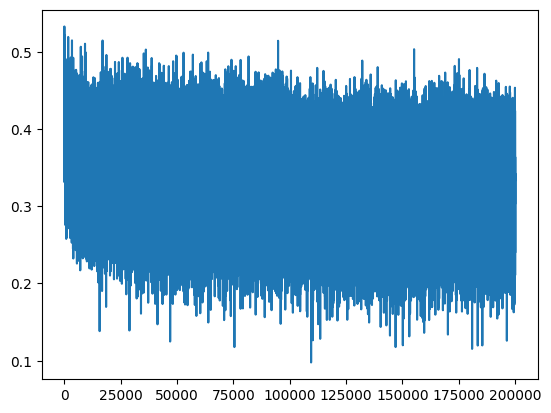

In [15]:
plt.plot(lossi)

In [17]:
@torch.no_grad() # disables gradient tracking here
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y) 
    
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056840419769287


In [13]:
# Sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(15):
    out = []
    context = [0] * block_size

    while True:
        # forward pass
        emb = C[torch.tensor([context])] 
        h = torch.tanh(emb.view(1, -1) @ W1 + b1) 
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # Take sample
        idx = torch.multinomial(probs, num_samples=1, generator=g).item()

        # Shift context window
        context = context[1:] + [idx]
        out.append(idx)
        
        # Check for special '.' token
        if idx == 0:
            break

    print(''.join(itos[i] for i in out)) # print gen'd word

carpah.
amorie.
khirmy.
xhetty.
salayson.
mahnen.
den.
art.
kaqui.
nellara.
chaiir.
kaleigh.
ham.
jorn.
quintis.


## Code Torchification ##

Now I'll torchify the code, so that it appears more like the pytorch library.

In [22]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros((fan_out)) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

In [23]:
class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = 0.1
        self.training = True
        # parameters
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers that update with a running momentum update
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        # update buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

In [24]:
class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [56]:
n_embd = 10 # dimensionality of embedding vectors
n_hidden = 100 # NO. neurons in the hidden layer
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size)
]

with torch.no_grad():
    layers[-1].gamma *= 0.1 # Make last layer less confident
    # Apply gain to other layers
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # Total NO. parameters
for p in parameters:
    p.requires_grad = True

47551


In [57]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # Minibatch construct
    idx = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[idx], Ytr[idx]

    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1) # concat vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update via GD
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters]) # track parameter updates
        
    # Take out to run full training loop
    if i > 1000:
        break

      0/ 200000: 3.2870


After one run, the code below will vizualize the distribution of the activation values in each layer

layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.97%
layer 5 (      Tanh): mean +0.01, std 0.64, saturated: 2.41%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.44%
layer 11 (      Tanh): mean +0.00, std 0.64, saturated: 2.22%
layer 14 (      Tanh): mean -0.00, std 0.64, saturated: 2.25%


Text(0.5, 1.0, 'activation distribution')

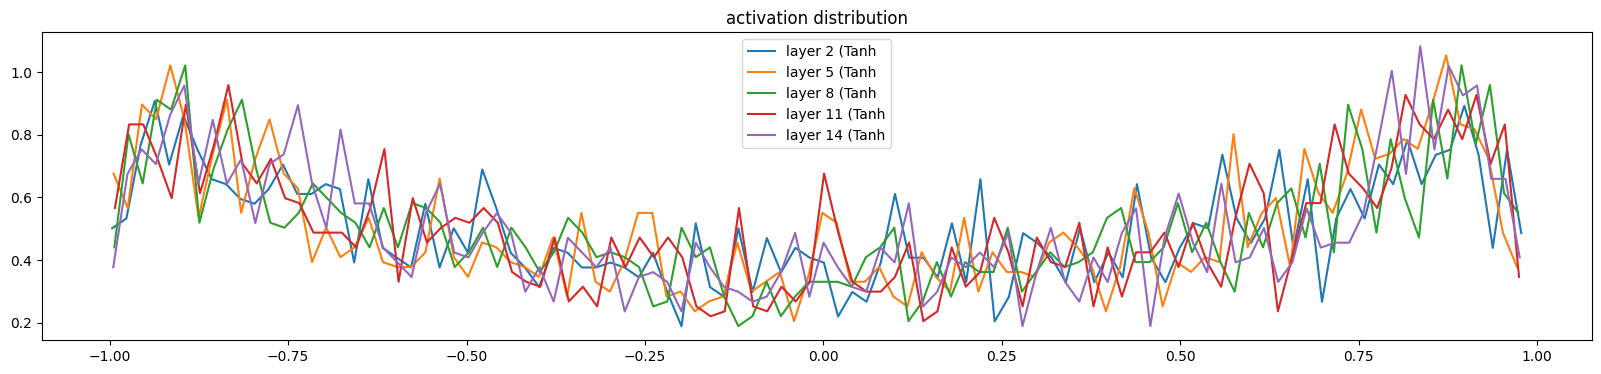

In [58]:
plt.figure(figsize=(20,4))
legends=[]
for i, layer in enumerate(layers[:-1]): # exclude output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends)
plt.title('activation distribution')

The same idea also works for the gradients:

layer 2 (      Tanh): mean -0.000000, std 3.561985e-03
layer 5 (      Tanh): mean -0.000000, std 3.119529e-03
layer 8 (      Tanh): mean +0.000000, std 2.904408e-03
layer 11 (      Tanh): mean +0.000000, std 2.580225e-03
layer 14 (      Tanh): mean +0.000000, std 2.440871e-03


Text(0.5, 1.0, 'gradient distribution')

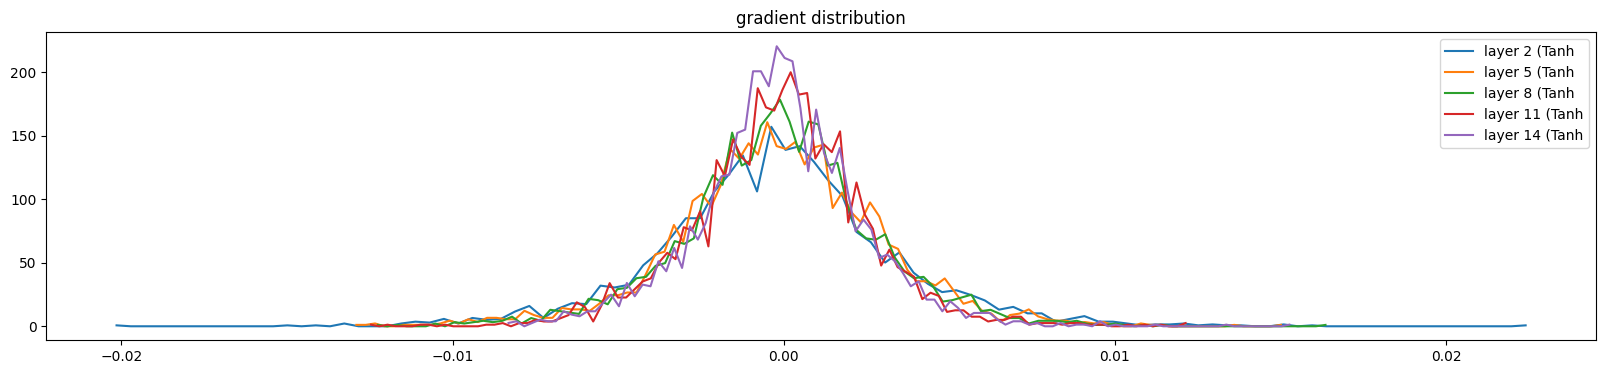

In [59]:
plt.figure(figsize=(20,4))
legends=[]
for i, layer in enumerate(layers[:-1]): # exclude output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends)
plt.title('gradient distribution')

Next I'll graph the distribution of the weights:

weight   (27, 10) | mean -0.000000 | std 8.198658e-03 | grad:data ratio 8.190299e-03
weight  (30, 100) | mean -0.000195 | std 7.650399e-03 | grad:data ratio 2.447698e-02
weight (100, 100) | mean -0.000097 | std 6.207576e-03 | grad:data ratio 3.712878e-02
weight (100, 100) | mean +0.000015 | std 5.561921e-03 | grad:data ratio 3.297630e-02
weight (100, 100) | mean +0.000008 | std 5.220603e-03 | grad:data ratio 3.110152e-02
weight (100, 100) | mean +0.000029 | std 4.829163e-03 | grad:data ratio 2.876370e-02
weight  (100, 27) | mean -0.000014 | std 9.281216e-03 | grad:data ratio 5.568818e-02


Text(0.5, 1.0, 'Weight gradient distribution')

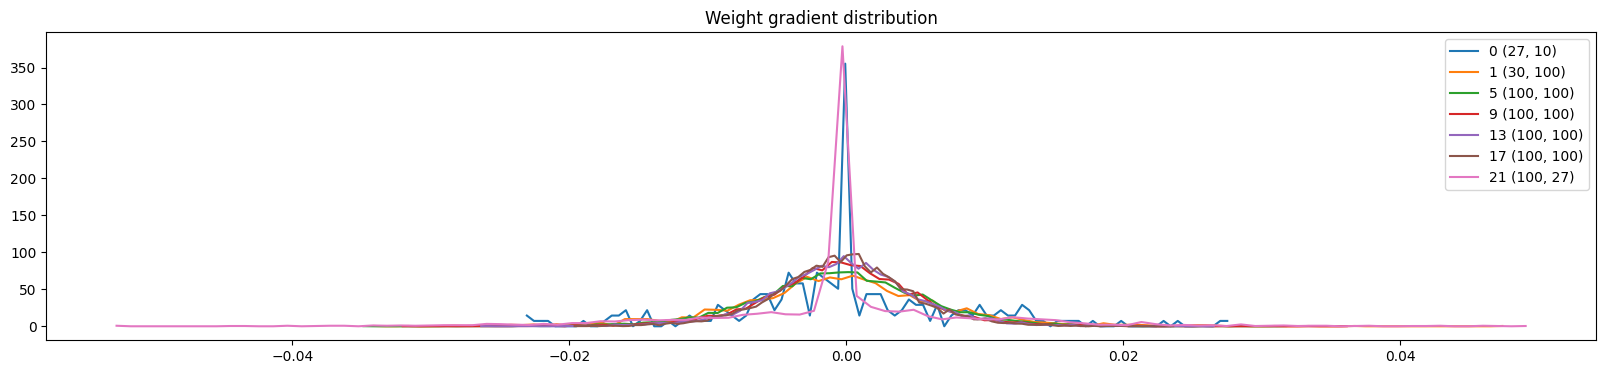

In [63]:
plt.figure(figsize=(20,4))
legends=[]
for i, p in enumerate(parameters): # exclude output layer
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('Weight gradient distribution')

As more training is done (e.g., 1000 steps), the gradients begin to stabilize.

Gradient to data ratio is not that informative, instead the update to data ratio is as this demonstrates how much we're actually changing the data.

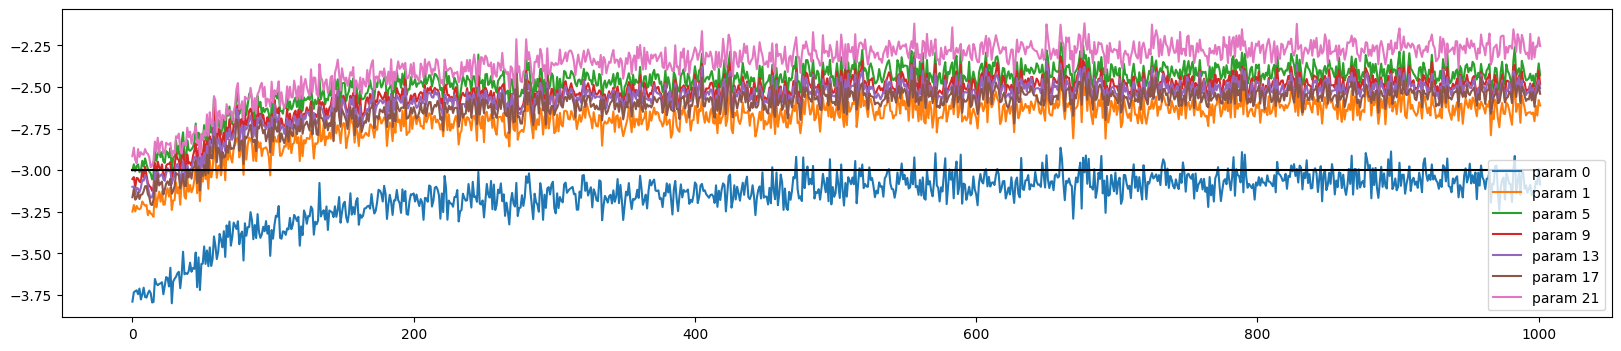

In [62]:
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

The last layer is an outlier as we multiply the final layer by 0.1, which made the tensor values too low and thus high changes, however this value can be seen to go down.

The ratio should be around 1e-3, below that mean the model isn't training enough, above that is likely too much.

Using batchnorm before tanh will improve the graph results. The parameters train at roughly the same rate.

Overall, batch norm is good for maintaining a stand